# Insurance Cost Forecasting Model

## Import Libs

In [63]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [64]:
# Deep learning (PyTorch)
import torch
from torch import nn

### Import Scaled Dataset

In [65]:
# Import scaled dataset
df = pd.read_csv("datasets/transformed_data.csv")
df

,age,sex,bmi,children,smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest
0,-1.438764,False,-0.453320,0,True,16884.92400,False,False,False,True
1,-1.509965,True,0.509621,1,False,1725.55230,False,False,True,False
2,-0.797954,True,0.383307,3,False,4449.46200,False,False,True,False
3,-0.441948,True,-1.305531,0,False,21984.47061,False,True,False,False
4,-0.513149,True,-0.292556,0,False,3866.85520,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...
1333,0.768473,True,0.050297,3,False,10600.54830,False,True,False,False
1334,-1.509965,False,0.206139,0,False,2205.98080,True,False,False,False
1335,-1.509965,False,1.014878,0,False,1629.83350,False,False,True,False
1336,-1.296362,False,-0.797813,0,False,2007.94500,False,False,False,True


## Train Test data splitting

In [66]:
features = ["age", "sex", "bmi", "children", "smoker", "region_northeast", "region_northwest", "region_southeast", "region_southwest"]
X = df[features]
y = df["charges"]

X.head(), y.head()

(        age    sex       bmi  children  smoker  region_northeast  \
 0 -1.438764  False -0.453320         0    True             False   
 1 -1.509965   True  0.509621         1   False             False   
 2 -0.797954   True  0.383307         3   False             False   
 3 -0.441948   True -1.305531         0   False             False   
 4 -0.513149   True -0.292556         0   False             False   
 
    region_northwest  region_southeast  region_southwest  
 0             False             False              True  
 1             False              True             False  
 2             False              True             False  
 3              True             False             False  
 4              True             False             False  ,
 0    16884.92400
 1     1725.55230
 2     4449.46200
 3    21984.47061
 4     3866.85520
 Name: charges, dtype: float64)

In [67]:
X.shape, y.shape

((1338, 9), (1338,))

### Convert all data to Tensors

In [68]:
X.values

array([[-1.438764260264482, False, -0.4533200014601978, ..., False,
        False, True],
       [-1.5099654504939408, True, 0.5096210969173165, ..., False, True,
        False],
       [-0.7979535481993532, True, 0.3833068472153252, ..., False, True,
        False],
       ...,
       [-1.5099654504939408, False, 1.014878095725279, ..., False, True,
        False],
       [-1.2963618798055645, False, -0.797813409738354, ..., False,
        False, True],
       [1.5516857293727864, False, -0.2613879597052247, ..., True, False,
        False]], shape=(1338, 9), dtype=object)

In [69]:
# Force all boolean values to become 0s or 1s, bcz boolean values get converted to objects,
# these objects can not be converted into tensors
X = X.astype(float)
y = y.astype(float)

# Convert to numpy array then to tensors
X_tensor = torch.tensor(X.values, dtype=torch.float32)
y_tensor = torch.tensor(y.values, dtype=torch.float32)

X_tensor.shape, y_tensor.shape

(torch.Size([1338, 9]), torch.Size([1338]))

In [70]:
# Train - Test splitting

X_train, X_test, y_train, y_test = train_test_split(X_tensor, y_tensor, test_size=0.2, random_state=42)

X_train, X_test, y_train, y_test

(tensor([[ 0.4837,  0.0000, -1.7575,  ...,  1.0000,  0.0000,  0.0000],
         [ 0.5549,  0.0000, -1.0406,  ...,  0.0000,  0.0000,  0.0000],
         [ 0.9109,  0.0000, -0.9520,  ...,  0.0000,  1.0000,  0.0000],
         ...,
         [ 1.3381,  1.0000, -0.9003,  ...,  0.0000,  0.0000,  0.0000],
         [-0.1571,  0.0000,  2.7784,  ...,  0.0000,  0.0000,  1.0000],
         [ 1.1245,  1.0000, -0.1252,  ...,  0.0000,  0.0000,  1.0000]]),
 tensor([[ 0.4125,  0.0000, -0.9003,  ...,  0.0000,  0.0000,  0.0000],
         [-0.2283,  0.0000, -0.1055,  ...,  1.0000,  0.0000,  0.0000],
         [ 1.7653,  0.0000, -0.6198,  ...,  1.0000,  0.0000,  0.0000],
         ...,
         [-0.0859,  1.0000, -0.4328,  ...,  0.0000,  0.0000,  0.0000],
         [ 1.0533,  0.0000,  2.7472,  ...,  0.0000,  1.0000,  0.0000],
         [ 0.8397,  0.0000,  0.5802,  ...,  0.0000,  0.0000,  1.0000]]),
 tensor([ 9193.8389,  8534.6719, 27117.9941,  ..., 11931.1250, 46113.5117,
         10214.6357]),
 tensor([ 9095.068

In [71]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

(torch.Size([1070, 9]),
 torch.Size([268, 9]),
 torch.Size([1070]),
 torch.Size([268]))

In [72]:
# Normalize the target so MSE is computed on a stable scale
y_train_mean = y_train.mean()
y_train_std = y_train.std()

y_train_norm = (y_train - y_train_mean) / y_train_std
y_test_norm = (y_test - y_train_mean) / y_train_std

y_train_norm.shape, y_test_norm.shape

(torch.Size([1070]), torch.Size([268]))

### Visualize

In [73]:
# Define a visualization function

def plot_predictions(train_data=X_train,
                     train_labels=y_train,
                     test_data=X_test,
                     test_labels=y_test,
                     predictions=None):
    """
    Plot training and testing data and compares predictions
    """

    fig, ax = plt.subplots(1, 2, figsize=(15, 5))

    # Training data
    ax[0].scatter(train_data[:, 0], train_labels, c="blue", s=10, alpha=0.8, label="Training data")
    ax[1].scatter(train_data[:, 2], train_labels, c="blue", s=10, alpha=0.8, label="Training data")

    # Testing data
    ax[0].scatter(test_data[:, 0], test_labels, c="green", s=10, alpha=0.8, label="Testing data")
    ax[1].scatter(test_data[:, 2], test_labels, c="green", s=10, alpha=0.8, label="Testing data")

    # Plot predictions if any
    if predictions is not None:
        ax[0].scatter(test_data[:, 0], y=predictions, c="red", s=10, alpha=0.8, label="Predictions")
        ax[1].scatter(test_data[:, 2], y=predictions, c="red", s=10, alpha=0.8, label="Predictions")

    ax[0].set_title("Charges vs Age")
    ax[1].set_title("Charges vs BMI")

    # plt.figure(figsize=(15, 10))

    # # training data
    # plt.scatter(x=X_train, y=y_train, c="blue", s=10, alpha=0.8, label="Training data")

    # # testing data
    # plt.scatter(x=X_test, y=y_test, c="green", s=10, alpha=0.8, label="Testing data")

    # # Plot predictions if any
    # if predictions is not None:
    #     plt.scatter(x=X_test, y=predictions, c="red", s=10, alpha=0.8, label="Predictions")

    # plt.legend(props={"size": 14})

    plt.show()

In [74]:
X.shape, y.shape

((1338, 9), (1338,))

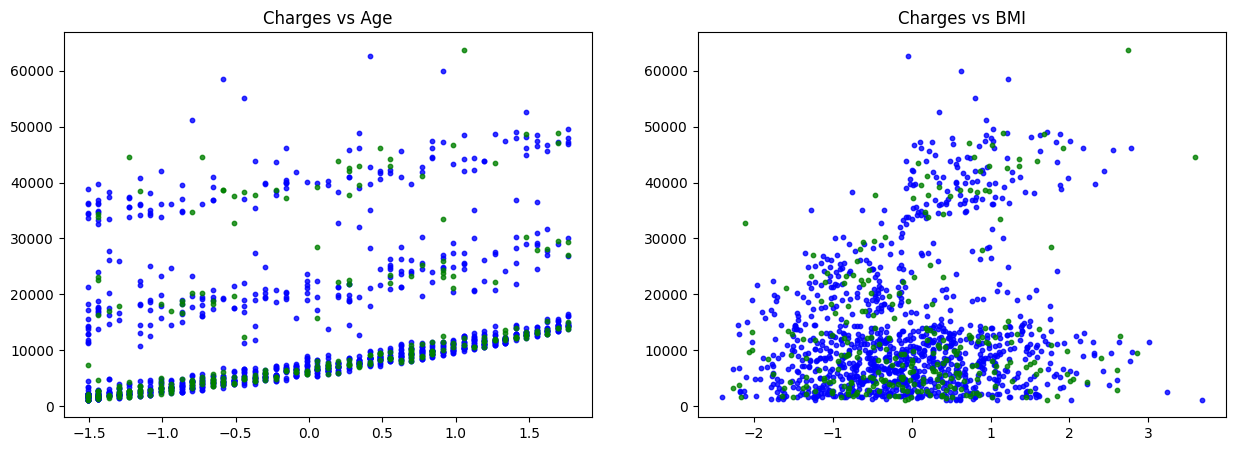

In [75]:
plot_predictions()

### Model architecture

It is a simple Linear-Regression model with multiple input features

In [76]:
X_train

tensor([[ 0.4837,  0.0000, -1.7575,  ...,  1.0000,  0.0000,  0.0000],
        [ 0.5549,  0.0000, -1.0406,  ...,  0.0000,  0.0000,  0.0000],
        [ 0.9109,  0.0000, -0.9520,  ...,  0.0000,  1.0000,  0.0000],
        ...,
        [ 1.3381,  1.0000, -0.9003,  ...,  0.0000,  0.0000,  0.0000],
        [-0.1571,  0.0000,  2.7784,  ...,  0.0000,  0.0000,  1.0000],
        [ 1.1245,  1.0000, -0.1252,  ...,  0.0000,  0.0000,  1.0000]])

In [77]:
# Model architecture

class MultipleRegressionModel(nn.Module):
    def __init__(self):
        super().__init__()
        # 9 input features
        self.linear = nn.Linear(in_features=9, out_features=1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # No activation function for Multiple-Regression
        return self.linear(x)

In [78]:
# Instanciate model
model_V1 = MultipleRegressionModel()

In [79]:
# List model parameters
list(model_V1.parameters())

[Parameter containing:
 tensor([[ 0.2548,  0.2767, -0.0781,  0.3062, -0.0730,  0.0673, -0.1623,  0.1958,
           0.2938]], requires_grad=True),
 Parameter containing:
 tensor([-0.2445], requires_grad=True)]

In [80]:
model_V1.state_dict()

OrderedDict([('linear.weight',
              tensor([[ 0.2548,  0.2767, -0.0781,  0.3062, -0.0730,  0.0673, -0.1623,  0.1958,
                        0.2938]])),
             ('linear.bias', tensor([-0.2445]))])

### Make Random Predictions (Before Training)

In [81]:
with torch.inference_mode():
    y_preds_rand = model_V1(X_test)

y_preds_rand

tensor([[ 6.1055e-01],
        [-4.5678e-01],
        [ 1.8418e-02],
        [ 9.7472e-01],
        [-5.8595e-01],
        [ 3.8094e-01],
        [-6.6911e-01],
        [ 2.2695e-01],
        [-2.0932e-01],
        [ 9.9143e-01],
        [ 1.0847e+00],
        [ 5.1572e-01],
        [ 8.5962e-02],
        [ 1.0470e+00],
        [ 4.0076e-01],
        [ 8.0264e-01],
        [ 5.8739e-01],
        [ 2.4936e-01],
        [ 4.1416e-01],
        [-3.6263e-01],
        [ 1.6858e+00],
        [ 9.8240e-01],
        [-3.7315e-02],
        [-6.0661e-01],
        [ 7.4021e-01],
        [ 6.5311e-02],
        [ 3.6977e-01],
        [ 2.9366e-01],
        [ 6.2859e-01],
        [-1.5022e-01],
        [ 1.3060e+00],
        [-9.8849e-02],
        [-4.3304e-01],
        [ 4.8196e-01],
        [ 4.0103e-01],
        [ 8.7398e-02],
        [ 7.9751e-02],
        [ 4.3411e-01],
        [ 1.4217e-01],
        [ 3.4475e-01],
        [ 1.2401e+00],
        [-1.4498e-01],
        [ 5.9442e-01],
        [ 2

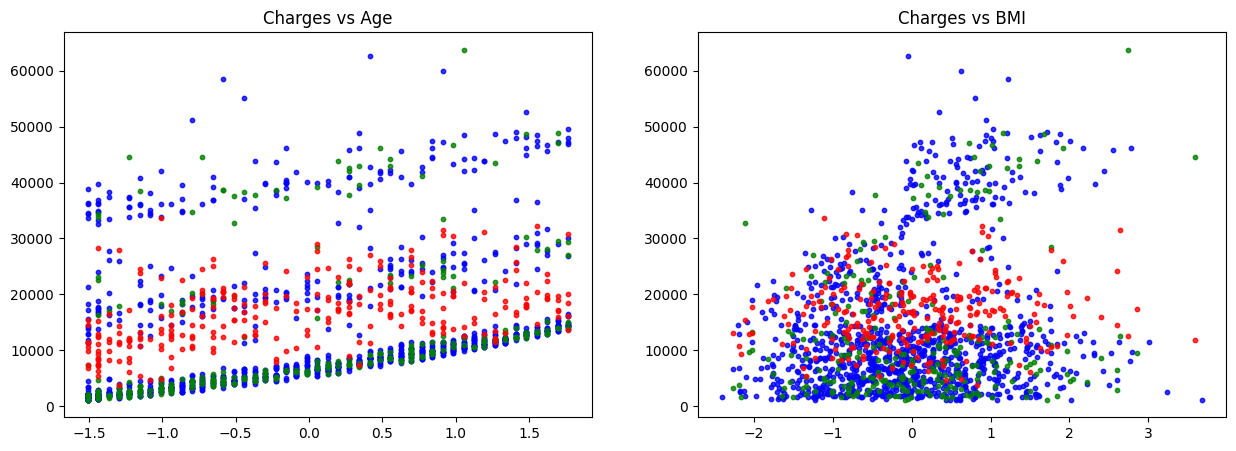

In [82]:
plot_predictions(predictions=y_preds_rand * y_train_std + y_train_mean)

### Loss function and Optimizer
- Loss function is required for calculating training and testing loss for each iteration
- Optimizer updates mmodel parameters based on training

In [83]:
# MSE loss function
loss_fn = nn.MSELoss()

# Adam optimizer
optimizer = torch.optim.Adam(model_V1.parameters(), lr=0.005)

## Training and Testing Loop

For building a training loop, we need:
1. Forward pass (this involves the data moving through our model's `forward()` functions) to make predictions on data - also called forward propagation
2. Calculate the loss (compare forward pass predictions to ground truth labels)
3. Optimizer zero grad
4. Loss backward - move backward through the network to calculate the gradients of each parameters of our model with respect to the loss (**Backpropagation**)
5. Optimizer step - use the optimizer to adjust our model's parameters to try and improve the loss (**Gradient descent**)

In [84]:
# Set random seed
torch.manual_seed(42)

# Number of iterations
epochs = 750

# Tracking model performance
epoch_count = []
loss_values = []
test_loss_values = []

# 0. Loop through data
for epoch in range(epochs):

    model_V1.train()

    ### Training loop
    # 1. Forward pass
    y_preds = model_V1(X_train).squeeze(dim=1)

    # 2. Calculate loss
    loss = loss_fn(y_preds, y_train_norm)
    print(f"Loss: {loss}")

    # 3. Optimizer zero grad
    optimizer.zero_grad()

    # 4. Perform backpropagation
    loss.backward()

    # 5. Optimizer step (perform gradient descent)
    optimizer.step()

    ### Testing
    model_V1.eval()     # Turn off different setting not needed for testing
    with torch.inference_mode():
        # 1. Forward pass
        test_preds = model_V1(X_test).squeeze(dim=1)

        # 2. Calculate loss
        test_loss = loss_fn(test_preds, y_test_norm)

    # Print model evaluations
    if epoch % 10 == 0:
        epoch_count.append(epoch)
        loss_values.append(loss)
        test_loss_values.append(test_loss)
        
        print(f"Epoch: {epoch} | Loss: {loss} | Test-loss: {test_loss}")

Loss: 1.2197182178497314
Epoch: 0 | Loss: 1.2197182178497314 | Test-loss: 1.2069404125213623
Loss: 1.1991674900054932
Loss: 1.1794178485870361
Loss: 1.1604622602462769
Loss: 1.1422780752182007
Loss: 1.124859094619751
Loss: 1.108214020729065
Loss: 1.0923517942428589
Loss: 1.077272891998291
Loss: 1.0629687309265137
Loss: 1.0494211912155151
Epoch: 10 | Loss: 1.0494211912155151 | Test-loss: 1.0570024251937866
Loss: 1.036605715751648
Loss: 1.0244945287704468
Loss: 1.0130585432052612
Loss: 1.00226628780365
Loss: 0.9920831322669983
Loss: 0.982470691204071
Loss: 0.9733885526657104
Loss: 0.9647936820983887
Loss: 0.9566444754600525
Loss: 0.9489004015922546
Epoch: 20 | Loss: 0.9489004015922546 | Test-loss: 0.9647244215011597
Loss: 0.9415236115455627
Loss: 0.9344780445098877
Loss: 0.9277288317680359
Loss: 0.9212422370910645
Loss: 0.9149859547615051
Loss: 0.9089298248291016
Loss: 0.9030466675758362
Loss: 0.8973129391670227
Loss: 0.8917088508605957
Loss: 0.8862175345420837
Epoch: 30 | Loss: 0.886217

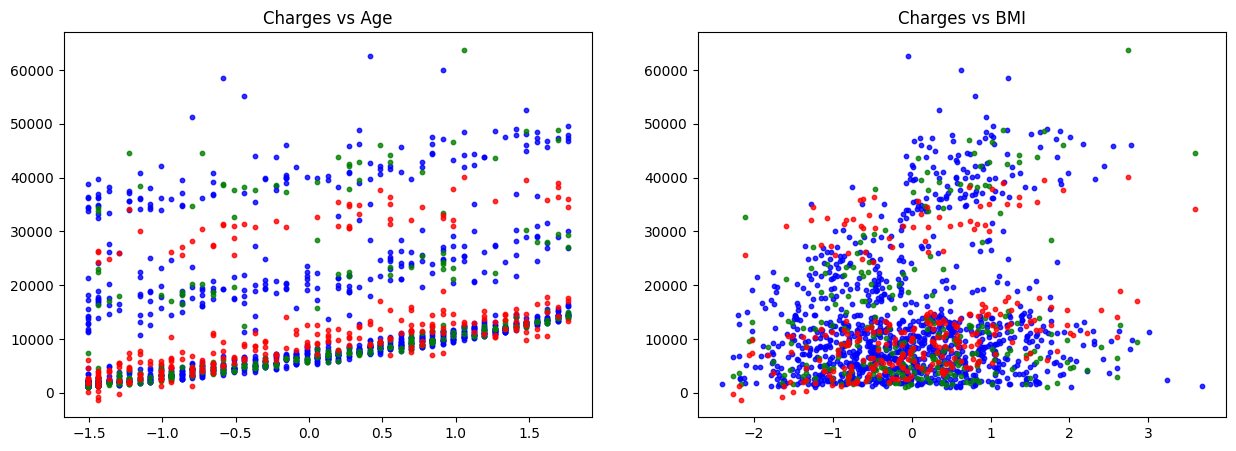

In [85]:
plot_predictions(predictions=test_preds * y_train_std + y_train_mean)

In [86]:
import numpy as np

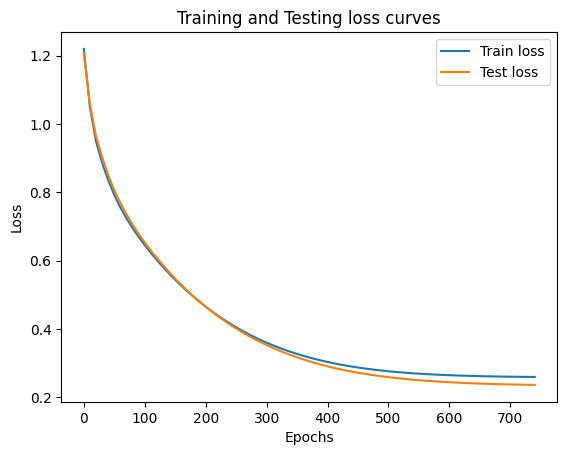

In [87]:
# Plot the loss curves
plt.plot(epoch_count, np.array(torch.tensor(loss_values).cpu().numpy()), label="Train loss")
plt.plot(epoch_count, test_loss_values, label="Test loss")
plt.title("Training and Testing loss curves")
plt.ylabel("Loss")
plt.xlabel("Epochs")
plt.legend()

### Dense NeuralNetwork Model (ModelV2)

Due to Under-fitting we are making making a model more complex by adding a activation function ReLU and add a hidden layer of 4 neurons

In [88]:
class DenseModel(nn.Module):
    def __init__(self):
        super().__init__()

        # Layer 1
        self.layer1 = nn.Linear(in_features=9, out_features=4)

        # ReLU activation
        self.relu = nn.ReLU()

        # Layer 2
        self.layer2 = nn.Linear(in_features=4, out_features=1)

    # forward pass
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.relu(self.layer1(x))
        return self.layer2(x)

In [89]:
model_V2 = DenseModel()

In [90]:
# MSE loss function (Same as before)
loss_fn = nn.MSELoss()

# Adam optimizer (Same as before)
optimizer = torch.optim.Adam(model_V2.parameters(), lr=0.005)

In [91]:
# Set random seed
torch.manual_seed(42)

# Number of iterations (Changed because of denser model, which easily learn complex patterns)
epochs = 500

# Tracking model performance
epoch_count = []
loss_values = []
test_loss_values = []

# 0. Loop through data
for epoch in range(epochs):

    model_V2.train()

    ### Training loop
    # 1. Forward pass
    y_preds = model_V2(X_train).squeeze(dim=1)

    # 2. Calculate loss
    loss = loss_fn(y_preds, y_train_norm)
    print(f"Loss: {loss}")

    # 3. Optimizer zero grad
    optimizer.zero_grad()

    # 4. Perform backpropagation
    loss.backward()

    # 5. Optimizer step (perform gradient descent)
    optimizer.step()

    ### Testing
    model_V2.eval()     # Turn off different setting not needed for testing
    with torch.inference_mode():
        # 1. Forward pass
        test_preds = model_V2(X_test).squeeze(dim=1)

        # 2. Calculate loss
        test_loss = loss_fn(test_preds, y_test_norm)

    # Print model evaluations
    if epoch % 10 == 0:
        epoch_count.append(epoch)
        loss_values.append(loss)
        test_loss_values.append(test_loss)
        
        print(f"Epoch: {epoch} | Loss: {loss} | Test-loss: {test_loss}")

Loss: 1.3706120252609253
Epoch: 0 | Loss: 1.3706120252609253 | Test-loss: 1.4050400257110596
Loss: 1.333264708518982
Loss: 1.298417091369629
Loss: 1.265998125076294
Loss: 1.2360150814056396
Loss: 1.208390235900879
Loss: 1.183025598526001
Loss: 1.1597623825073242
Loss: 1.1385633945465088
Loss: 1.1192967891693115
Loss: 1.1018455028533936
Epoch: 10 | Loss: 1.1018455028533936 | Test-loss: 1.1617372035980225
Loss: 1.0861445665359497
Loss: 1.0720502138137817
Loss: 1.0594173669815063
Loss: 1.0480923652648926
Loss: 1.037954568862915
Loss: 1.0289087295532227
Loss: 1.0207916498184204
Loss: 1.0135142803192139
Loss: 1.0069688558578491
Loss: 1.0010309219360352
Epoch: 20 | Loss: 1.0010309219360352 | Test-loss: 1.0597115755081177
Loss: 0.995603084564209
Loss: 0.990587592124939
Loss: 0.9858811497688293
Loss: 0.9814061522483826
Loss: 0.9770909547805786
Loss: 0.9728902578353882
Loss: 0.9687783122062683
Loss: 0.9646674990653992
Loss: 0.9605274796485901
Loss: 0.9563201665878296
Epoch: 30 | Loss: 0.9563201

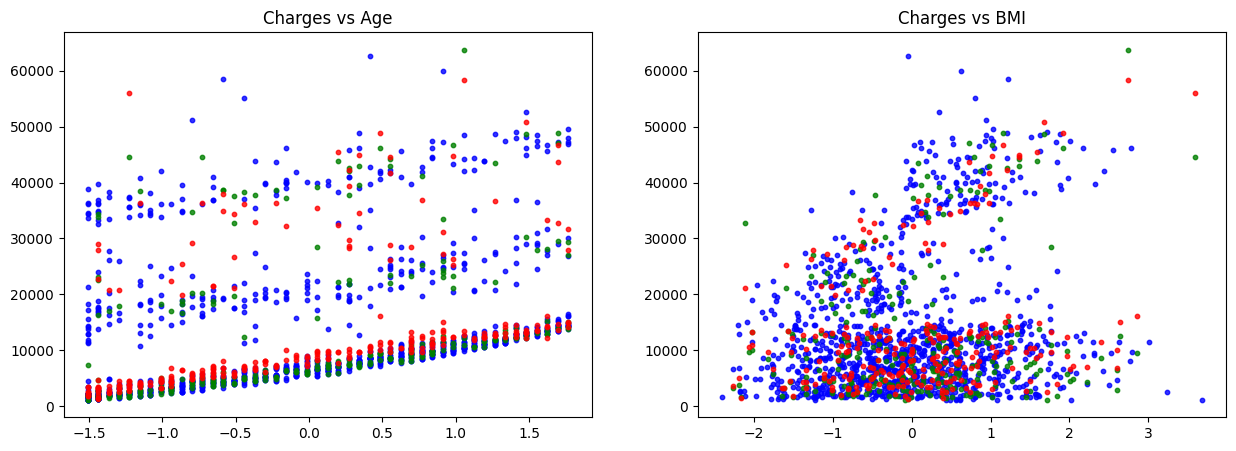

In [92]:
plot_predictions(predictions=test_preds * y_train_std + y_train_mean)

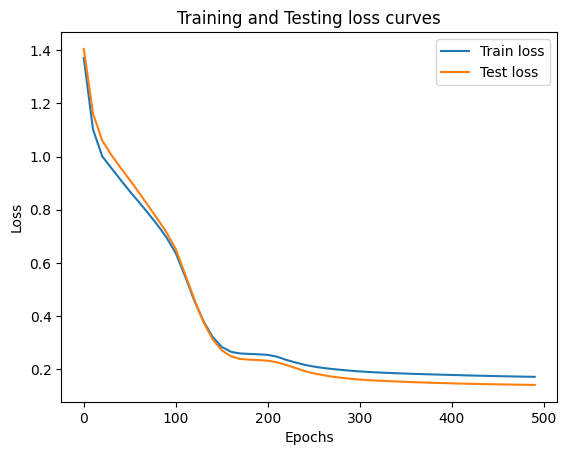

In [93]:
# Plot the loss curves
plt.plot(epoch_count, np.array(torch.tensor(loss_values).cpu().numpy()), label="Train loss")
plt.plot(epoch_count, test_loss_values, label="Test loss")
plt.title("Training and Testing loss curves")
plt.ylabel("Loss")
plt.xlabel("Epochs")
plt.legend()